# Resumen del proyecto — De 3 GB de texto a embeddings que entienden español

Recorrido por las seis fases del proyecto CBOW sobre el Spanish Billion Word
Corpus, con **un ejemplo y un gráfico por fase**. Cada gráfico está elegido para
que se vea *por qué* se tomó cada decisión, no solo qué se hizo.

Los notebooks 01 a 05 tienen el detalle de cada fase; este es el mapa.
Skip-gram vive en `../notebooks_SKIPGRAM/`, sobre el mismo `src/`.

| Fase | Qué resuelve | La decisión clave |
|---|---|---|
| 1 | Leer 3 GB que no entran en memoria | Streaming + tokenizador a medida del corpus |
| 2 | Elegir qué palabras entran | 5.000 palabras cubren el 83% del texto |
| 3 | Armar los ejemplos de entrenamiento | Conservar los bordes con relleno + máscara |
| 4 | Diseñar la red | Negative sampling en vez de softmax |
| 5 | Entrenar | 15 épocas, checkpoints, validación |
| 6 | Comprobar que sirve | Vecinos, analogías y exportación |

In [1]:
import math
import sys
import time
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np

from src.config import corpus_path, load_config, vocab_path
from src.vocabulary import Vocabulary

CONFIG = load_config("configs/piloto_5k_50_2.yaml")
VOCAB = Vocabulary.load(vocab_path(CONFIG))
MUESTRA = corpus_path(CONFIG)

plt.rcParams["figure.dpi"] = 110

print("Corpus completo   : 95.800.000 oraciones | 2.028.209.650 tokens | 2,97 GB")
print("Vocabulario       :", VOCAB)
print("Muestra de trabajo:", MUESTRA.name, f"({MUESTRA.stat().st_size / 1024**2:,.0f} MB)")

Corpus completo   : 95.800.000 oraciones | 2.028.209.650 tokens | 2,97 GB
Vocabulario       : Vocabulary(size=5000, total_tokens=2,028,209,650, coverage=0.8326, min_count=5)
Muestra de trabajo: muestra_2m.txt (242 MB)


---
# Fase 1 — Leer el corpus

**El problema:** 2,97 GB comprimidos, más de 12 GB descomprimidos. No entra en
memoria y no conviene descomprimirlo a disco.

**La solución:** generadores. Se lee de a una oración, descomprimiendo sobre la
marcha. La memoria usada no depende del tamaño del archivo.

In [2]:
from src.corpus import stream_sentences, tokenize

print("Tres oraciones del corpus, tal como salen:\n")
for oracion in stream_sentences(MUESTRA, limit=3):
    print(" ", oracion[:95])

Tres oraciones del corpus, tal como salen:

  El Sudán reafirma el derecho de los refugiados palestinos a regresar a sus hogares de conformid
  No sabemos qué clase de persona es ella Cómo podemos hacerlo
  Refrigeración por líquido temperatura máxima a la salida K


## La decisión: cómo tokenizar

El archivo se llama *clean*, pero contando sus caracteres apareció lo que
realmente tiene adentro. Ese inventario es el que definió el tokenizador.

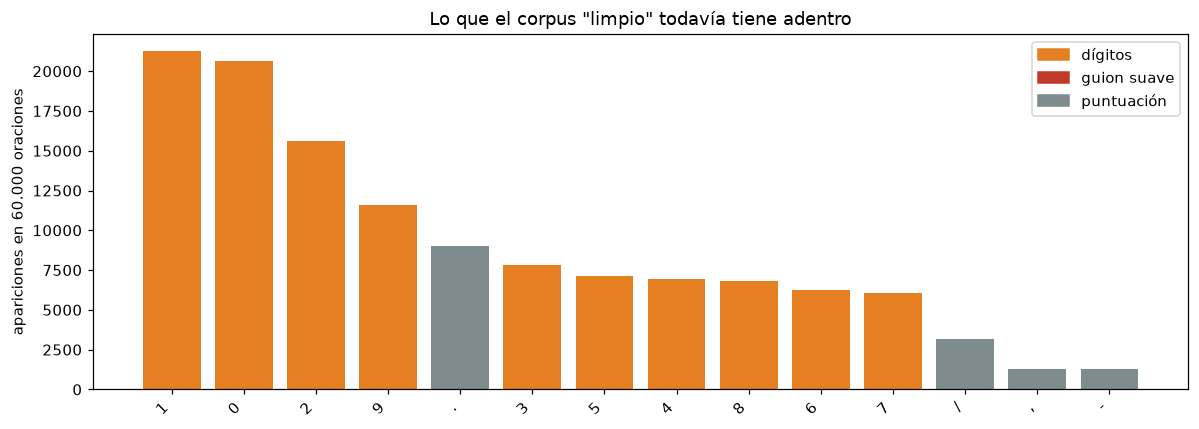

In [3]:
from collections import Counter
from src.corpus import open_corpus

caracteres = Counter()
with open_corpus(MUESTRA) as f:
    for i, linea in enumerate(f):
        if i >= 60_000:
            break
        caracteres.update(linea.strip())

no_alfa = {c: n for c, n in caracteres.items() if not c.isalpha() and c != " "}
top = sorted(no_alfa.items(), key=lambda x: -x[1])[:14]

etiquetas = [("guion suave\n(invisible)" if c == "\xad" else repr(c).strip("'")) for c, _ in top]
valores = [n for _, n in top]
colores = ["#c0392b" if c == "\xad" else ("#e67e22" if c.isdigit() else "#7f8c8d")
           for c, _ in top]

plt.figure(figsize=(11, 4))
plt.bar(etiquetas, valores, color=colores)
plt.ylabel("apariciones en 60.000 oraciones")
plt.title("Lo que el corpus \"limpio\" todavía tiene adentro")
plt.xticks(rotation=45, ha="right")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ["#e67e22", "#c0392b", "#7f8c8d"]]
plt.legend(handles, ["dígitos", "guion suave", "puntuación"], loc="upper right")
plt.tight_layout()
plt.show()

Dos hallazgos definieron el tokenizador:

* **Los dígitos son de los caracteres más frecuentes.** Aprender un vector para
  cada número sería desperdicio, así que todos se colapsan en `<NUM>`.
* **El guion suave** (rojo) es un carácter *invisible* metido dentro de las
  palabras. Si no se elimina, parte `ré·gimen` en dos tokens basura.

In [4]:
CASOS = [
    "El PIB creció 3.5% en 1999 y cayó 2,1 en 2000",
    "el acuerdo del 12/03/1998",
    "el r\u00e9\u00adgimen militar",         # con guion suave invisible
    "un acuerdo franco-alemán",
    "(hola) [chau] ¿qué? ¡sí!",
]
for texto in CASOS:
    print(f"  {texto!r}")
    print(f"     -> {tokenize(texto)}\n")

  'El PIB creció 3.5% en 1999 y cayó 2,1 en 2000'
     -> ['el', 'pib', 'creció', '<NUM>', 'en', '<NUM>', 'y', 'cayó', '<NUM>', 'en', '<NUM>']

  'el acuerdo del 12/03/1998'
     -> ['el', 'acuerdo', 'del', '<NUM>']

  'el ré\xadgimen militar'
     -> ['el', 'régimen', 'militar']

  'un acuerdo franco-alemán'
     -> ['un', 'acuerdo', 'franco-alemán']

  '(hola) [chau] ¿qué? ¡sí!'
     -> ['hola', 'chau', 'qué', 'sí']



Se lee ahí cada decisión: la fecha completa da **un solo** `<NUM>`, el guion
suave desaparece y la palabra queda entera, `franco-alemán` se conserva como una
unidad, y la puntuación separa sin generar tokens.

---
# Fase 2 — Construir el vocabulario

**El problema:** el corpus tiene millones de palabras distintas, y más de la
mitad aparecen una sola vez. No se pueden entrenar todas.

**La pregunta:** ¿cuánto texto se pierde si nos quedamos solo con las frecuentes?

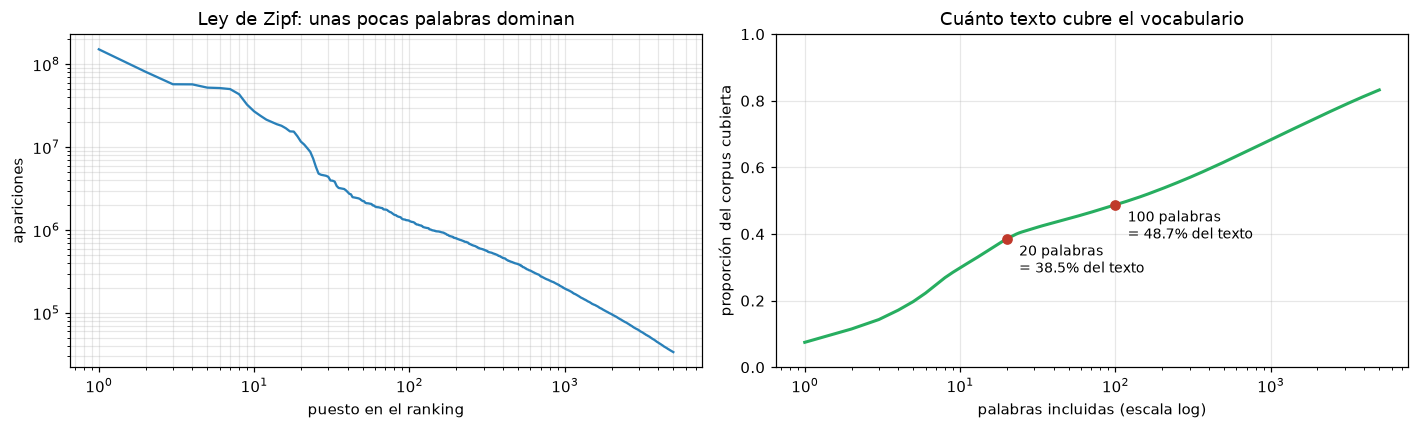

In [5]:
frecuencias = np.array(VOCAB.counts[1:], dtype=float)   # sin <UNK>
acumulado = np.cumsum(frecuencias) / VOCAB.total_tokens
rangos = np.arange(1, len(frecuencias) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].loglog(rangos, frecuencias, lw=1.5, color="#2980b9")
axes[0].set_title("Ley de Zipf: unas pocas palabras dominan")
axes[0].set_xlabel("puesto en el ranking"); axes[0].set_ylabel("apariciones")
axes[0].grid(alpha=0.3, which="both")

axes[1].semilogx(rangos, acumulado, lw=2, color="#27ae60")
for marca in (20, 100, 5000):
    if marca <= len(acumulado):
        y = acumulado[marca - 1]
        axes[1].plot(marca, y, "o", color="#c0392b")
        axes[1].annotate(f"{marca:,} palabras\n= {y:.1%} del texto", (marca, y),
                         textcoords="offset points", xytext=(8, -22), fontsize=9)
axes[1].set_ylim(0, 1)
axes[1].set_title("Cuánto texto cubre el vocabulario")
axes[1].set_xlabel("palabras incluidas (escala log)")
axes[1].set_ylabel("proporción del corpus cubierta")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Esa desproporción es la que hace viable todo el proyecto.** Con 5.000 palabras
—una fracción mínima de las que existen— se cubre el 83% del texto. El 17%
restante se reemplaza por un comodín, `<UNK>`.

In [6]:
print("Las 8 palabras más frecuentes del corpus:\n")
print(f"  {'#':>2} {'palabra':<10} {'apariciones':>16} {'% del corpus':>13}")
print("  " + "-" * 45)
for i, (palabra, cuenta) in enumerate(VOCAB.most_common(8), start=1):
    print(f"  {i:>2} {palabra:<10} {cuenta:>16,} {cuenta / VOCAB.total_tokens:>12.2%}")

print(f"\n  La palabra n.º 5.000 es '{VOCAB.itos[-1]}' y aparece "
      f"{VOCAB.counts[-1]:,} veces.")
print(f"  Todo lo que aparezca menos que eso cae en <UNK> "
      f"({1 - VOCAB.coverage:.1%} del corpus).")

Las 8 palabras más frecuentes del corpus:

   # palabra         apariciones  % del corpus
  ---------------------------------------------
   1 de              151,730,127        7.48%
   2 la               81,271,721        4.01%
   3 en               57,489,474        2.83%
   4 el               57,311,995        2.83%
   5 y                52,333,053        2.58%
   6 <NUM>            51,748,553        2.55%
   7 que              50,290,880        2.48%
   8 a                43,608,452        2.15%

  La palabra n.º 5.000 es 'cercana' y aparece 33,838 veces.
  Todo lo que aparezca menos que eso cae en <UNK> (16.7% del corpus).


---
# Fase 3 — Armar los ejemplos

**Qué es un ejemplo:** un par *contexto → target*. Se desliza una ventana por
cada oración y cada palabra, por turno, hace de target.

In [7]:
from src.dataset import generate_pairs, pad_context

DEMO = ROOT / "data" / "processed" / "_resumen" / "demo.txt"
DEMO.parent.mkdir(parents=True, exist_ok=True)
DEMO.write_text("el gato juega en la casa\n", encoding="utf-8")

print("Oración: el gato juega en la casa      (context_size = 2)\n")
print(f"  {'contexto':<28} {'target':<10} {'ancho'}")
print("  " + "-" * 48)
for contexto, target in generate_pairs(DEMO, VOCAB, 2, subsampling_threshold=0,
                                       **CONFIG["tokenizer"]):
    palabras = " ".join(VOCAB.word(i) for i in contexto)
    print(f"  {'[' + palabras + ']':<28} {VOCAB.word(target):<10} {len(contexto)}")

Oración: el gato juega en la casa      (context_size = 2)

  contexto                     target     ancho
  ------------------------------------------------
  [gato juega]                 el         2
  [el juega en]                gato       3
  [el gato en la]              juega      4
  [gato juega la casa]         en         4
  [juega en casa]              la         3
  [en la]                      casa       2


Fijate en la última columna: **el ancho del contexto varía** (2, 3, 4, 4, 3, 2).
Las palabras de los bordes tienen menos vecinas. Como las redes necesitan
tensores rectangulares, había que decidir qué hacer con eso.

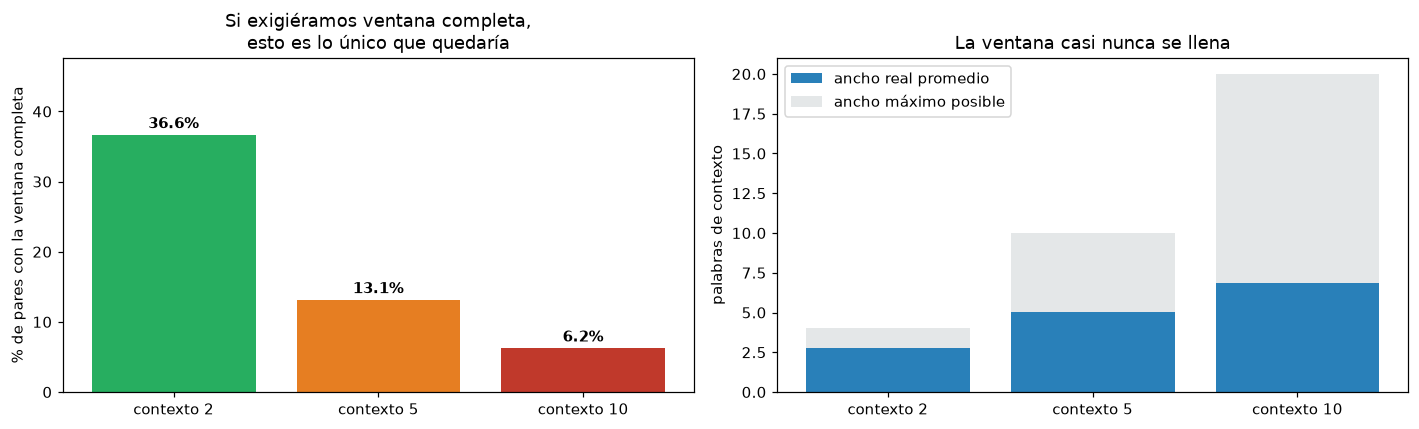

In [8]:
# ¿Cuántos pares tienen la ventana COMPLETA, según el tamaño de contexto?
N = 20_000
opciones = dict(seed=42, drop_unknown=True, subsampling_threshold=1e-5,
                **CONFIG["tokenizer"])

contextos, completos, anchos = [], [], []
for c in (2, 5, 10):
    largos = [len(x) for x, _ in generate_pairs(MUESTRA, VOCAB, c, limit=N, **opciones)]
    contextos.append(c)
    completos.append(100 * sum(1 for a in largos if a == 2 * c) / len(largos))
    anchos.append(sum(largos) / len(largos))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

barras = axes[0].bar([f"contexto {c}" for c in contextos], completos,
                     color=["#27ae60", "#e67e22", "#c0392b"])
for barra, valor in zip(barras, completos):
    axes[0].text(barra.get_x() + barra.get_width() / 2, valor + 1,
                 f"{valor:.1f}%", ha="center", fontweight="bold")
axes[0].set_ylabel("% de pares con la ventana completa")
axes[0].set_title("Si exigiéramos ventana completa,\nesto es lo único que quedaría")
axes[0].set_ylim(0, max(completos) * 1.3)

axes[1].bar([f"contexto {c}" for c in contextos], anchos, color="#2980b9",
            label="ancho real promedio")
axes[1].bar([f"contexto {c}" for c in contextos], [2 * c for c in contextos],
            color="#bdc3c7", alpha=0.4, zorder=0, label="ancho máximo posible")
axes[1].set_ylabel("palabras de contexto")
axes[1].set_title("La ventana casi nunca se llena")
axes[1].legend()

plt.tight_layout()
plt.show()

**La decisión:** conservar todos los pares, rellenando hasta el ancho máximo y
acompañando una **máscara** que marca qué posiciones son reales.

El gráfico explica por qué: con contexto 10, exigir ventana completa tiraría el
**99,7%** de los ejemplos. La máscara le dice al modelo que promedie solo las
posiciones reales, sin contar el relleno.

In [9]:
for contexto, descripcion in [([12, 45], "borde de la oración"),
                              ([12, 45, 7, 9], "medio de la oración")]:
    indices, mascara = pad_context(contexto, 2)
    print(f"  {descripcion}")
    print(f"     contexto original : {contexto}")
    print(f"     relleno a 4       : {indices}")
    print(f"     máscara           : {mascara}   -> promedia sobre {sum(mascara)}\n")

import shutil
shutil.rmtree(DEMO.parent)

  borde de la oración
     contexto original : [12, 45]
     relleno a 4       : [12, 45, 0, 0]
     máscara           : [1, 1, 0, 0]   -> promedia sobre 2

  medio de la oración
     contexto original : [12, 45, 7, 9]
     relleno a 4       : [12, 45, 7, 9]
     máscara           : [1, 1, 1, 1]   -> promedia sobre 4



---
# Fase 4 — El modelo

Una red diminuta: **500.000 números** (dos matrices de 5.000 palabras × 50
dimensiones). Sin capas ocultas ni activaciones. El contexto se resume
promediando, y la salida se calcula con *negative sampling*.

Dos decisiones se justifican solas al medirlas.

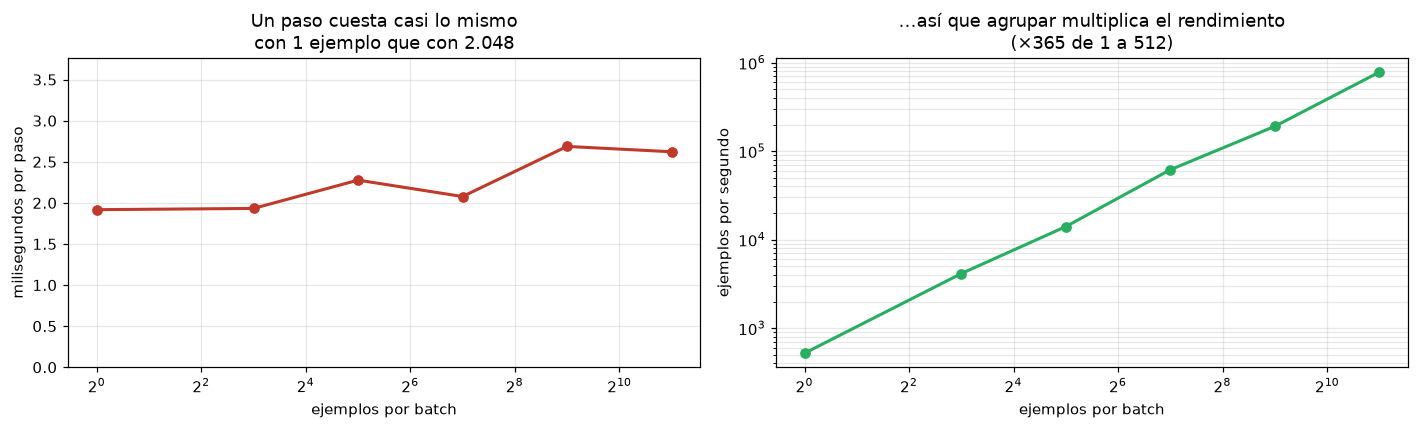

con batch de 1   :        522 ejemplos/s  ->  2.7 horas por época
con batch de 512 :    190,542 ejemplos/s  ->  0.4 minutos por época


In [10]:
import torch
from src.model import CBOWModel, NegativeSampler

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
V, D, K, ANCHO = len(VOCAB), CONFIG["embedding_dim"], CONFIG["negative_samples"], 4

modelo = CBOWModel(V, D, seed=1).to(DEVICE)
muestreador = NegativeSampler(VOCAB.counts, seed=1).to(DEVICE)
optimizador = torch.optim.Adam(modelo.parameters(), lr=0.003)

def medir(batch, repeticiones=100):
    ctx = torch.randint(0, V, (batch, ANCHO), device=DEVICE)
    msk = torch.ones(batch, ANCHO, device=DEVICE)
    tgt = torch.randint(0, V, (batch,), device=DEVICE)
    neg = muestreador.sample(batch, K)

    def paso():
        optimizador.zero_grad()
        modelo.negative_sampling_loss(ctx, msk, tgt, neg).backward()
        optimizador.step()

    for _ in range(10):
        paso()
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(repeticiones):
        paso()
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    dt = (time.time() - t0) / repeticiones
    return dt * 1000, batch / dt

TAMANOS = [1, 8, 32, 128, 512, 2048]
ms, rendimiento = zip(*[medir(b) for b in TAMANOS])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(TAMANOS, ms, "o-", lw=2, color="#c0392b")
axes[0].set_xscale("log", base=2)
axes[0].set_ylim(0, max(ms) * 1.4)
axes[0].set_xlabel("ejemplos por batch"); axes[0].set_ylabel("milisegundos por paso")
axes[0].set_title("Un paso cuesta casi lo mismo\ncon 1 ejemplo que con 2.048")
axes[0].grid(alpha=0.3)

axes[1].plot(TAMANOS, rendimiento, "o-", lw=2, color="#27ae60")
axes[1].set_xscale("log", base=2); axes[1].set_yscale("log")
axes[1].set_xlabel("ejemplos por batch"); axes[1].set_ylabel("ejemplos por segundo")
axes[1].set_title(f"...así que agrupar multiplica el rendimiento\n"
                  f"(×{rendimiento[TAMANOS.index(512)] / rendimiento[0]:,.0f} de 1 a 512)")
axes[1].grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

print(f"con batch de 1   : {rendimiento[0]:>10,.0f} ejemplos/s  ->  "
      f"{5_061_115 / rendimiento[0] / 3600:.1f} horas por época")
print(f"con batch de 512 : {rendimiento[TAMANOS.index(512)]:>10,.0f} ejemplos/s  ->  "
      f"{5_061_115 / rendimiento[TAMANOS.index(512)] / 60:.1f} minutos por época")

**Por qué batches:** el tiempo por paso casi no cambia, porque ese tiempo es
sobre todo *costo fijo* de lanzar el trabajo en la GPU, no cálculo. Con un solo
ejemplo, miles de núcleos quedan ociosos. El batch los llena.

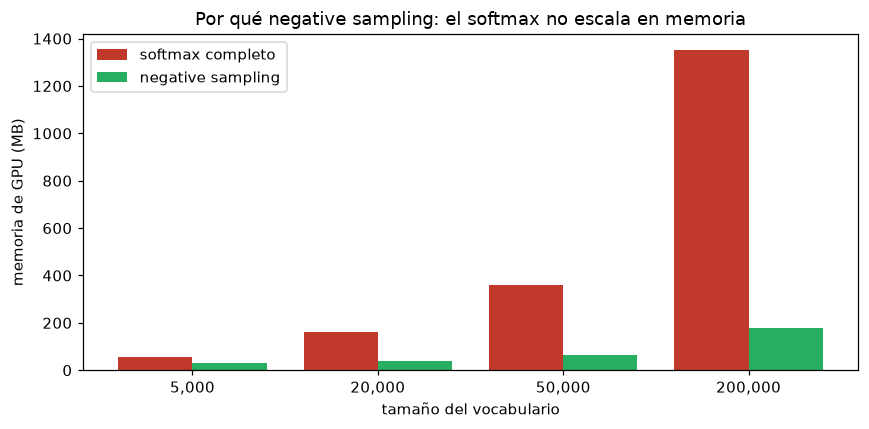

A vocabulario 200.000: 1,351 MB contra 180 MB (8 veces más).


In [11]:
# Negative sampling vs softmax completo: memoria según el tamaño del vocabulario
from torch import nn

entropia = nn.CrossEntropyLoss()
vocabularios = [5_000, 20_000, 50_000, 200_000]
mem_ns, mem_sm = [], []

for tam in vocabularios:
    m = CBOWModel(tam, D, seed=1).to(DEVICE)
    s = NegativeSampler([10] * tam).to(DEVICE)
    ctx = torch.randint(0, tam, (512, ANCHO), device=DEVICE)
    msk = torch.ones(512, ANCHO, device=DEVICE)
    tgt = torch.randint(0, tam, (512,), device=DEVICE)
    neg = s.sample(512, K)

    if DEVICE == "cuda":
        torch.cuda.reset_peak_memory_stats()
        m.negative_sampling_loss(ctx, msk, tgt, neg).backward()
        mem_ns.append(torch.cuda.max_memory_allocated() / 1024**2)
        torch.cuda.reset_peak_memory_stats()
        entropia(m.full_softmax_logits(ctx, msk), tgt).backward()
        mem_sm.append(torch.cuda.max_memory_allocated() / 1024**2)
    else:
        mem_ns.append(float("nan")); mem_sm.append(float("nan"))

x = np.arange(len(vocabularios))
plt.figure(figsize=(8, 4))
plt.bar(x - 0.2, mem_sm, 0.4, label="softmax completo", color="#c0392b")
plt.bar(x + 0.2, mem_ns, 0.4, label="negative sampling", color="#27ae60")
plt.xticks(x, [f"{v:,}" for v in vocabularios])
plt.xlabel("tamaño del vocabulario"); plt.ylabel("memoria de GPU (MB)")
plt.title("Por qué negative sampling: el softmax no escala en memoria")
plt.legend()
plt.tight_layout()
plt.show()

print(f"A vocabulario 200.000: {mem_sm[-1]:,.0f} MB contra {mem_ns[-1]:,.0f} MB "
      f"({mem_sm[-1] / mem_ns[-1]:.0f} veces más).")

**Por qué negative sampling:** el softmax tiene que puntuar *todas* las palabras
del vocabulario en cada paso, y guardar esa matriz para calcular los gradientes.
El negative sampling puntúa la correcta y 10 sorteadas — su costo **no depende
del vocabulario**. Con 5.000 palabras la diferencia es chica; al escalar, es lo
que hace que el mismo código siga funcionando.

---
# Fase 5 — El entrenamiento

15 épocas sobre 2 millones de oraciones (**75 millones de ejemplos**), 57 minutos.
Cada época evalúa contra un conjunto reservado que el modelo nunca ve, y guarda
un checkpoint.

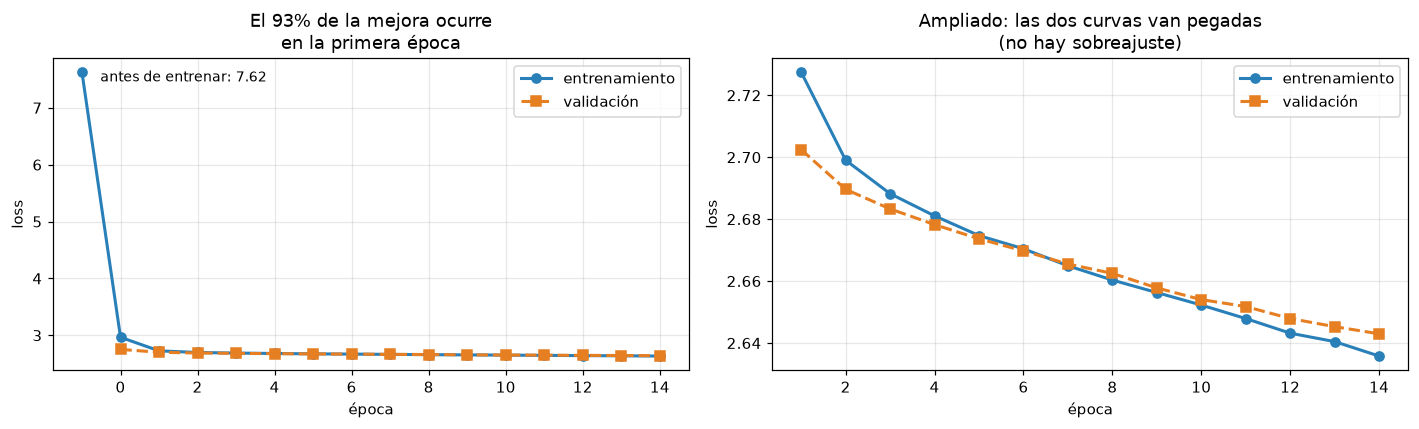

loss antes de entrenar : 7.6246
loss al final          : 2.6358 (validación 2.6430)
diferencia entre ambas : 0.0072  -> el modelo aprendió, no memorizó
mejora de la época 10 a la 14: 0.0111  -> con 10 épocas alcanzaba


In [12]:
from src.train import load_history

historia = load_history(CONFIG)
epocas = [e["epoch"] for e in historia]
entrenamiento = [e["train_loss"] for e in historia]
validacion = [e["val_loss"] for e in historia]
inicial = (1 + K) * math.log(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot([-1] + epocas, [inicial] + entrenamiento, "o-", lw=2,
             label="entrenamiento", color="#2980b9")
axes[0].plot(epocas, validacion, "s--", lw=2, label="validación", color="#e67e22")
axes[0].annotate(f"antes de entrenar: {inicial:.2f}", (-1, inicial),
                 textcoords="offset points", xytext=(12, -6), fontsize=9)
axes[0].set_xlabel("época"); axes[0].set_ylabel("loss")
axes[0].set_title("El 93% de la mejora ocurre\nen la primera época")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epocas[1:], entrenamiento[1:], "o-", lw=2, label="entrenamiento",
             color="#2980b9")
axes[1].plot(epocas[1:], validacion[1:], "s--", lw=2, label="validación",
             color="#e67e22")
axes[1].set_xlabel("época"); axes[1].set_ylabel("loss")
axes[1].set_title("Ampliado: las dos curvas van pegadas\n(no hay sobreajuste)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"loss antes de entrenar : {inicial:.4f}")
print(f"loss al final          : {entrenamiento[-1]:.4f} (validación {validacion[-1]:.4f})")
print(f"diferencia entre ambas : {abs(entrenamiento[-1] - validacion[-1]):.4f}  "
      f"-> el modelo aprendió, no memorizó")
print(f"mejora de la época 10 a la 14: {validacion[10] - validacion[-1]:.4f}  "
      f"-> con 10 épocas alcanzaba")

Las dos curvas pegadas son la señal de que **el modelo aprendió en vez de
memorizar**: si estuviera memorizando, la de validación se despegaría hacia
arriba. Con 500.000 parámetros y 5 millones de ejemplos por época, no tiene
dónde memorizar.

---
# Fase 6 — ¿Sirven los embeddings?

Que la loss baje solo prueba que el modelo resolvió *su* tarea. La prueba real
es geométrica: **palabras parecidas tienen que haber quedado cerca**.

In [13]:
from src.evaluate import evaluate_analogies, load_embeddings, nearest_neighbors, word_analogy

E, _ = load_embeddings(CONFIG)

print("VECINOS MÁS CERCANOS (nadie le enseñó estas categorías)\n")
for palabra in ["febrero", "tres", "rojo", "lunes", "argentina", "presidente"]:
    vecinos = nearest_neighbors(palabra, E, VOCAB, k=5)
    print(f"  {palabra:<12} -> " + ", ".join(f"{w} ({s:.2f})" for w, s in vecinos))

VECINOS MÁS CERCANOS (nadie le enseñó estas categorías)

  febrero      -> marzo (0.98), abril (0.98), octubre (0.98), mayo (0.97), julio (0.97)
  tres         -> cuatro (0.96), dos (0.95), cinco (0.92), siete (0.90), ocho (0.89)
  rojo         -> azul (0.93), blanco (0.88), negro (0.87), amarillo (0.85), color (0.80)
  lunes        -> viernes (0.93), jueves (0.88), sábado (0.86), horario (0.76), horas (0.75)
  argentina    -> argentino (0.77), republica (0.76), chile (0.72), paraguay (0.71), mendoza (0.69)
  presidente   -> presidenta (0.85), vicepresidente (0.83), presidencia (0.79), embajador (0.74), comisario (0.74)


In [14]:
print("ANALOGÍAS  (la dirección de 'a' a 'b', aplicada a 'c')\n")
for a, b, c, esperada in [("madrid", "españa", "roma", "italia"),
                          ("argentina", "argentino", "chile", "chileno"),
                          ("hombre", "mujer", "padre", "madre"),
                          ("año", "años", "día", "días")]:
    resultado = word_analogy(a, b, c, E, VOCAB, k=3)
    marca = "OK" if resultado[0][0] == esperada else "~ "
    print(f"  {marca}  {a} : {b}  ::  {c} : ?")
    print(f"      -> " + ", ".join(f"{w} ({s:.2f})" for w, s in resultado))

ANALOGÍAS  (la dirección de 'a' a 'b', aplicada a 'c')

  OK  madrid : españa  ::  roma : ?
      -> italia (0.73), francia (0.70), grecia (0.70)
  OK  argentina : argentino  ::  chile : ?
      -> chileno (0.88), santiago (0.73), colombia (0.69)
  OK  hombre : mujer  ::  padre : ?
      -> madre (0.73), hermana (0.69), matrimonio (0.68)
  OK  año : años  ::  día : ?
      -> días (0.76), meses (0.64), hace (0.61)


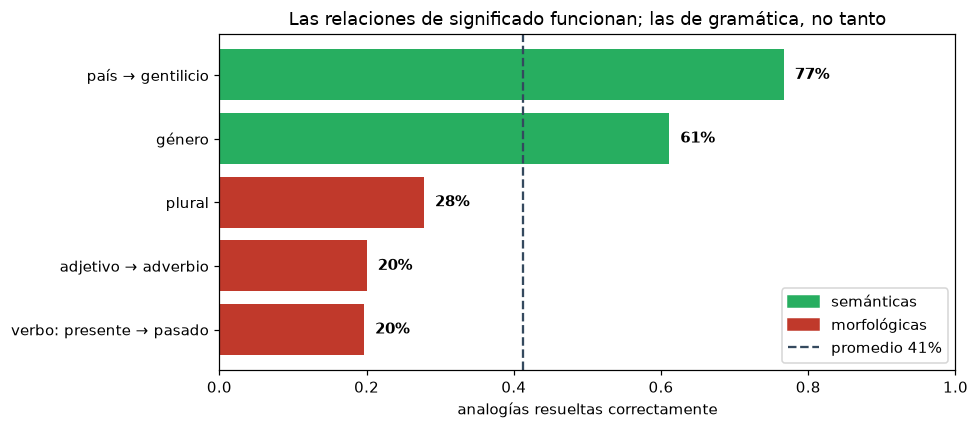

In [15]:
reporte = evaluate_analogies(E, VOCAB, k=1)
categorias = list(reporte["categories"])
precisiones = [reporte["categories"][c]["accuracy"] for c in categorias]
# semánticas vs morfológicas
es_semantica = ["género" in c or "gentilicio" in c for c in categorias]
colores = ["#27ae60" if s else "#c0392b" for s in es_semantica]

orden = np.argsort(precisiones)
plt.figure(figsize=(9, 4))
barras = plt.barh([categorias[i] for i in orden], [precisiones[i] for i in orden],
                  color=[colores[i] for i in orden])
for i, indice in enumerate(orden):
    plt.text(precisiones[indice] + 0.015, i, f"{precisiones[indice]:.0%}",
             va="center", fontweight="bold")
plt.axvline(reporte["accuracy"], ls="--", c="#34495e", lw=1.5,
            label=f"promedio {reporte['accuracy']:.0%}")
plt.xlim(0, 1)
plt.xlabel("analogías resueltas correctamente")
plt.title("Las relaciones de significado funcionan; las de gramática, no tanto")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ["#27ae60", "#c0392b"]]
plt.legend(handles + [plt.Line2D([], [], ls="--", c="#34495e")],
           ["semánticas", "morfológicas", f"promedio {reporte['accuracy']:.0%}"],
           loc="lower right")
plt.tight_layout()
plt.show()

Ese contraste es el hallazgo más útil del proyecto: el modelo entiende **de qué
se habla** pero no **cómo se conjuga**. Tiene una explicación directa —la ventana
de contexto es de solo 2 palabras a cada lado, suficiente para el tema y corta
para la sintaxis— y es una hipótesis que la Fase 7 puede poner a prueba subiendo
el contexto.

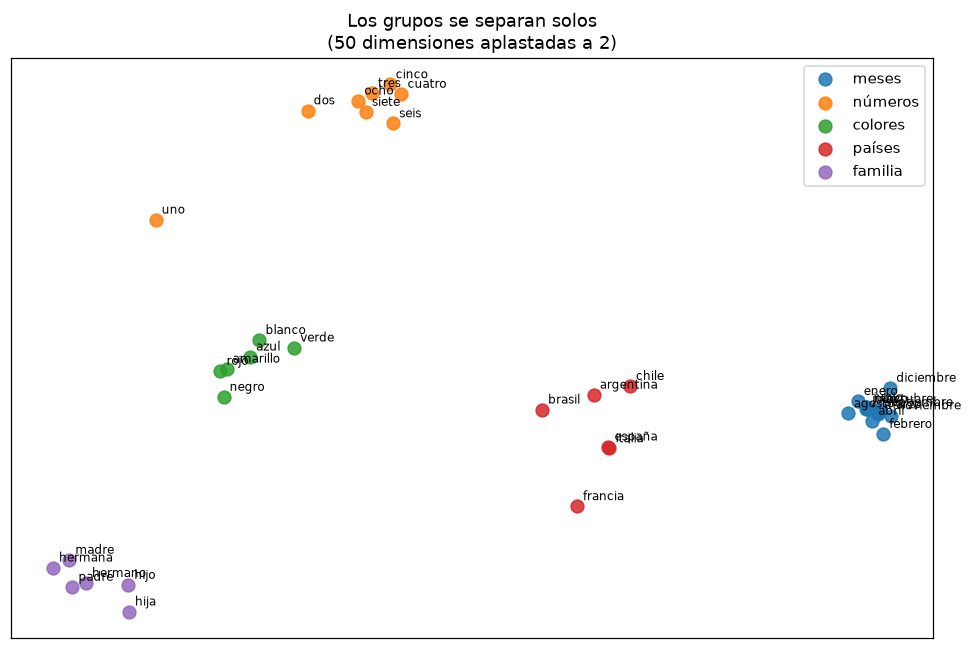

In [16]:
from sklearn.decomposition import PCA

GRUPOS = {
    "meses": ["enero", "febrero", "marzo", "abril", "mayo", "junio", "julio",
              "agosto", "septiembre", "octubre", "noviembre", "diciembre"],
    "números": ["uno", "dos", "tres", "cuatro", "cinco", "seis", "siete", "ocho"],
    "colores": ["rojo", "azul", "verde", "negro", "blanco", "amarillo"],
    "países": ["argentina", "chile", "brasil", "españa", "francia", "italia"],
    "familia": ["padre", "madre", "hijo", "hija", "hermano", "hermana"],
}

palabras, grupos = [], []
for grupo, lista in GRUPOS.items():
    for palabra in lista:
        if palabra in VOCAB:
            palabras.append(palabra); grupos.append(grupo)

matriz = np.array([E[VOCAB.index(w)] for w in palabras])
proyeccion = PCA(n_components=2, random_state=42).fit_transform(matriz)

plt.figure(figsize=(9, 6))
for grupo in GRUPOS:
    idx = [i for i, g in enumerate(grupos) if g == grupo]
    if idx:
        plt.scatter(proyeccion[idx, 0], proyeccion[idx, 1], s=70, label=grupo, alpha=0.85)
for i, palabra in enumerate(palabras):
    plt.annotate(palabra, proyeccion[i], fontsize=8, xytext=(4, 4),
                 textcoords="offset points")
plt.title("Los grupos se separan solos\n(50 dimensiones aplastadas a 2)")
plt.xticks([]); plt.yticks([])
plt.legend()
plt.tight_layout()
plt.show()

Cada color es una categoría que **el modelo nunca supo que existía**. Las agrupó
a partir de una única señal: qué palabras aparecen cerca de cuáles.

---
# El proyecto de un vistazo

In [17]:
from src.export import embeddings_path

etapas = [
    ("Corpus comprimido", "2,97 GB", "95,8M oraciones"),
    ("Tokens tras limpiar", "2.028.209.650", "21,2 por oración"),
    ("Vocabulario", f"{len(VOCAB):,} palabras", f"cubre el {VOCAB.coverage:.1%} del texto"),
    ("Ejemplos por época", "5.061.115", "pares contexto → target"),
    ("Modelo", "500.000 parámetros", f"{len(VOCAB):,} × {CONFIG['embedding_dim']} × 2 matrices"),
    ("Entrenamiento", "15 épocas / 57 min", f"loss {(1 + K) * math.log(2):.2f} → "
     f"{historia[-1]['train_loss']:.2f}"),
    ("Analogías resueltas", f"{reporte['accuracy']:.1%}", f"{reporte['correct']}/{reporte['evaluated']}"),
    ("Embeddings exportados",
     f"{embeddings_path(CONFIG).stat().st_size / 1024**2:.2f} MB", "formato Word2Vec"),
]

print(f"  {'ETAPA':<24} {'VALOR':<20} DETALLE")
print("  " + "=" * 72)
for etapa, valor, detalle in etapas:
    print(f"  {etapa:<24} {valor:<20} {detalle}")

  ETAPA                    VALOR                DETALLE
  Corpus comprimido        2,97 GB              95,8M oraciones
  Tokens tras limpiar      2.028.209.650        21,2 por oración
  Vocabulario              5,000 palabras       cubre el 83.3% del texto
  Ejemplos por época       5.061.115            pares contexto → target
  Modelo                   500.000 parámetros   5,000 × 50 × 2 matrices
  Entrenamiento            15 épocas / 57 min   loss 7.62 → 2.64
  Analogías resueltas      41.3%                118/286
  Embeddings exportados    2.31 MB              formato Word2Vec


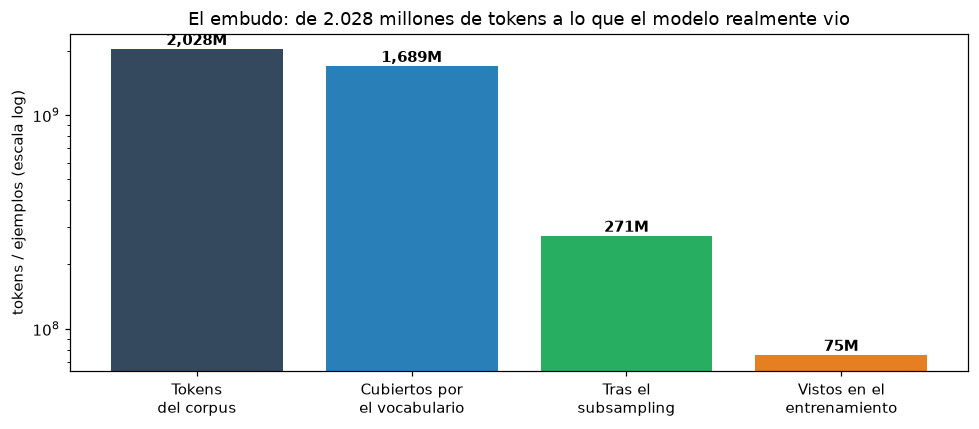

Cada escalón es una decisión de diseño:
  - el vocabulario de 5,000 deja fuera el 16.7% del texto
  - el subsampling descarta ocurrencias de las palabras muy frecuentes
  - las 15 épocas vuelven a recorrer la muestra, con un sorteo distinto cada vez


In [18]:
# De dónde a dónde: el embudo del corpus
niveles = ["Tokens\ndel corpus", "Cubiertos por\nel vocabulario",
           "Tras el\nsubsampling", "Vistos en el\nentrenamiento"]
valores = [
    VOCAB.total_tokens,
    VOCAB.total_tokens - VOCAB.unk_count,
    271_235_960,                                  # estimado en la Fase 2
    sum(e["pairs"] for e in historia),
]

plt.figure(figsize=(9, 4))
barras = plt.bar(niveles, valores, color=["#34495e", "#2980b9", "#27ae60", "#e67e22"])
for barra, valor in zip(barras, valores):
    plt.text(barra.get_x() + barra.get_width() / 2, valor * 1.05,
             f"{valor / 1e6:,.0f}M", ha="center", fontweight="bold")
plt.yscale("log")
plt.ylabel("tokens / ejemplos (escala log)")
plt.title("El embudo: de 2.028 millones de tokens a lo que el modelo realmente vio")
plt.tight_layout()
plt.show()

print("Cada escalón es una decisión de diseño:")
print(f"  - el vocabulario de {len(VOCAB):,} deja fuera el {1 - VOCAB.coverage:.1%} del texto")
print("  - el subsampling descarta ocurrencias de las palabras muy frecuentes")
print("  - las 15 épocas vuelven a recorrer la muestra, con un sorteo distinto cada vez")

## Lo que se aprendió por el camino

Tres cosas que no estaban en el plan y salieron de medir:

1. **El corpus está ordenado por fuente.** Arranca con texto coránico y sigue con
   actas parlamentarias, así que tomar "las primeras N oraciones" no da una
   muestra del español. Las primeras 200.000 oraciones tienen 26,8 tokens por
   oración y el corpus real tiene 21,2.
2. **`<UNK>` nunca se entrena.** Como las palabras fuera de vocabulario se
   eliminan, ese token jamás recibe un gradiente: su vector quedó en la
   inicialización aleatoria (norma 0,04 contra 3,20 del resto). Por eso no se
   exporta.
3. **Las palabras más frecuentes tienen vectores más *cortos*.** `de` aparece en
   contextos tan variados que sus actualizaciones se cancelan entre sí; `italia`
   se ve siempre en el mismo ambiente y su vector se estira en una dirección
   clara.

## Dónde está el detalle

| Notebook | Contenido |
|---|---|
| `01_exploracion_corpus` | Lectura por streaming y tokenización |
| `02_vocabulario` | Zipf, cobertura, `min_count`, poda, subsampling |
| `03_generacion_pares` | Ventana, relleno y máscara, los dos datasets |
| `04_entrenamiento` | Arquitectura, negative sampling, loop y checkpoints |
| `05_evaluacion_embeddings` | Vecinos, analogías, PCA, t-SNE y exportación |